### Import necessary libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from sklearn.utils import shuffle
from skimage.transform import resize
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

### Fetch the image data

In [4]:
with_mask = glob.glob('with_mask 1/with_mask 1/*.jpg')
without_mask = glob.glob('without_mask/without_mask/*.jpg')

In [5]:
len(with_mask)

1696

In [6]:
len(without_mask)

1792

### store all the images inside a list and create a list with corresponding labels

In [8]:
image = []
label = []

for i in with_mask:
    img = plt.imread(i)
    image.append(img)
    label.append(0)

for i in without_mask:
    img = plt.imread(i)
    image.append(img)
    label.append(1)

### Shuffle both images and labels

In [10]:
image,label = shuffle(image,label,random_state=100)

### Plot a few images of Both categories

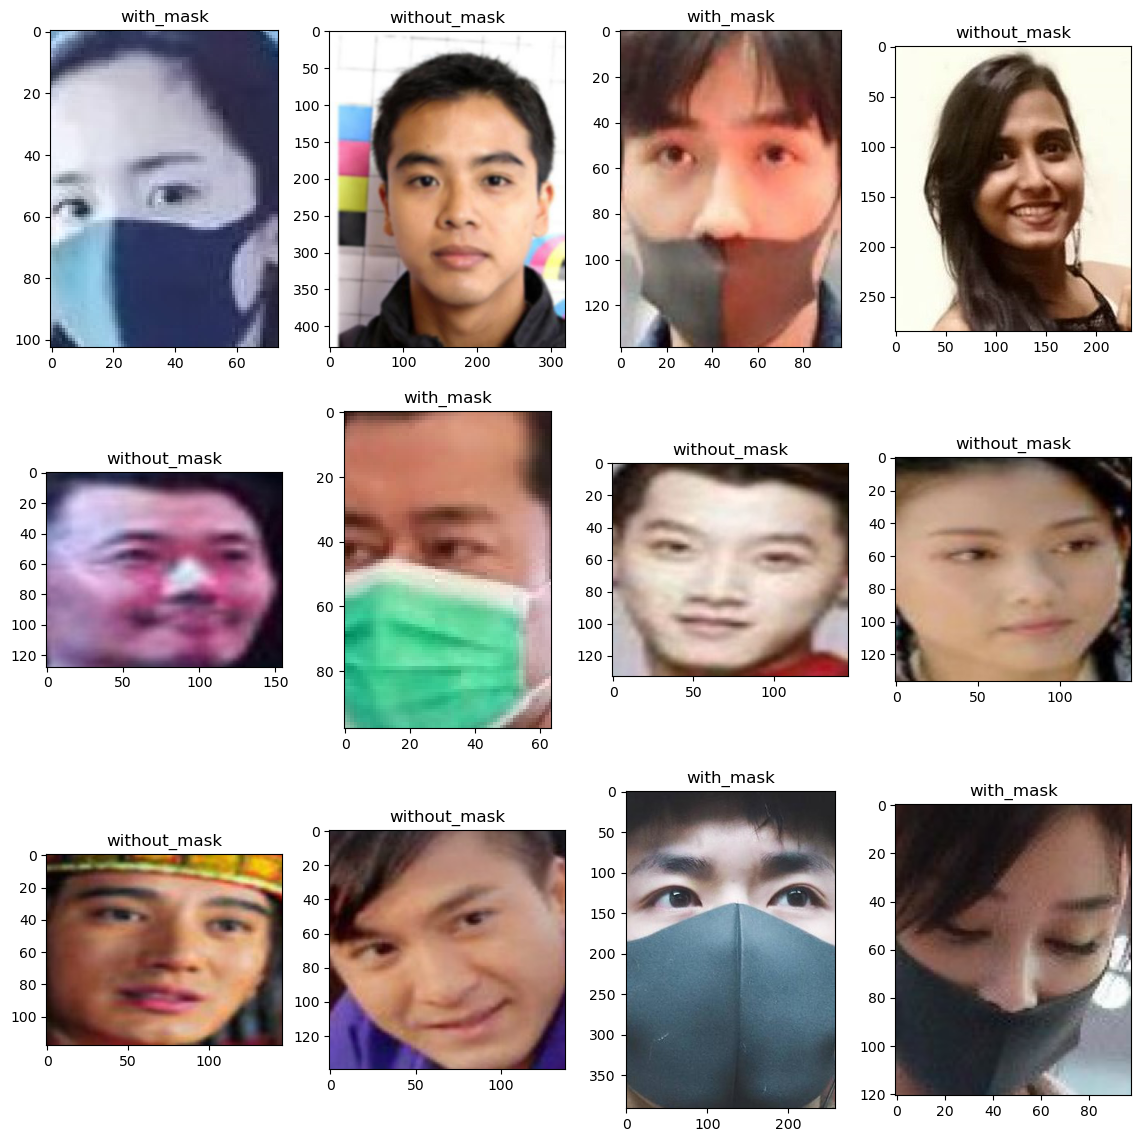

In [12]:
plt.figure(figsize=(14,14))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(image[i])
    if label[i] == 0:
        plt.title('with_mask')
    else:
        plt.title('without_mask')

### Resize the image to 64X64

In [14]:
X = []

for i in image:
    X.append(resize(i,(64,64,3)))

X = np.array(X)

### Plot some of the resized images

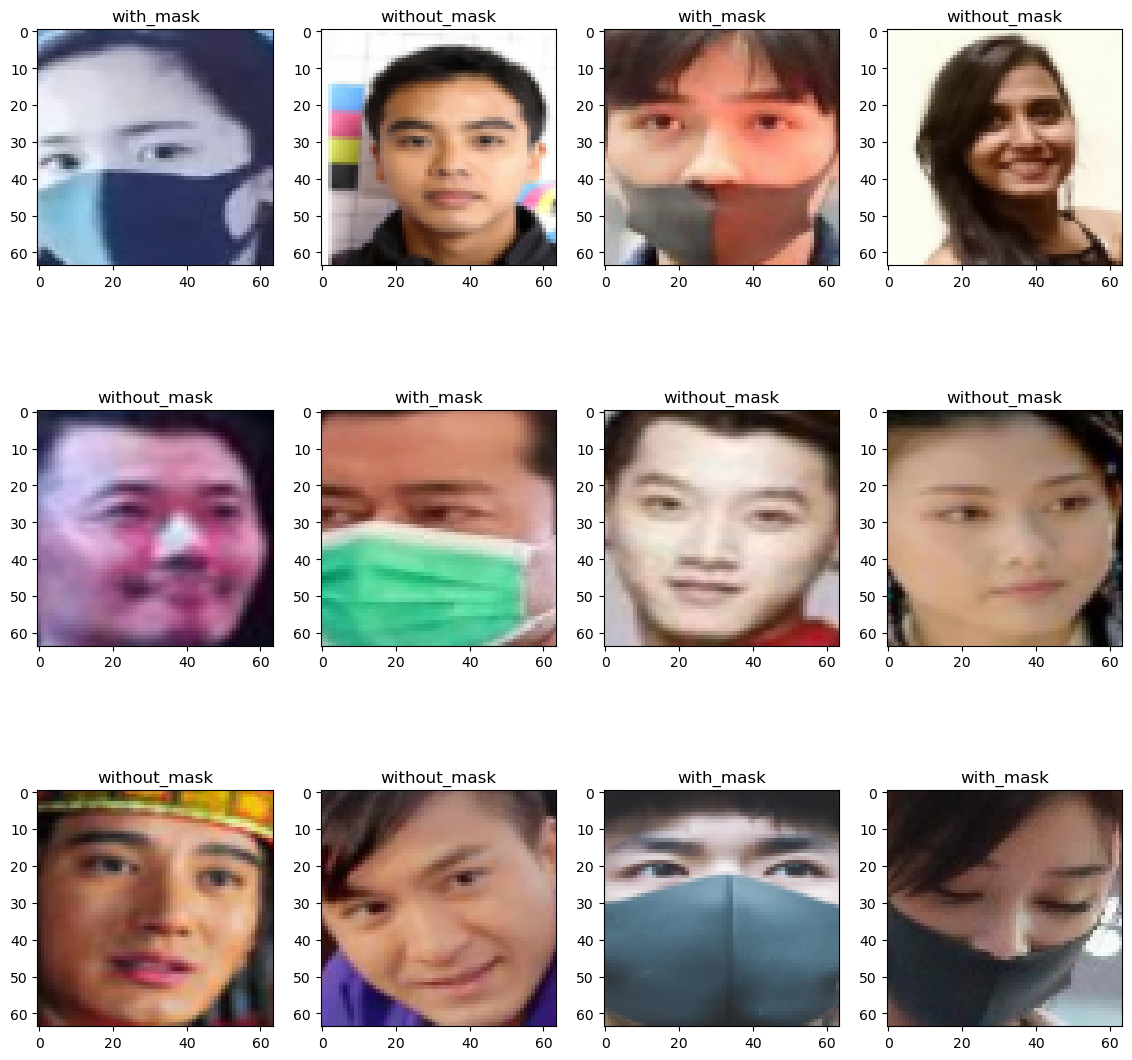

In [16]:
plt.figure(figsize=(14,14))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X[i])
    if label[i] == 0:
        plt.title('with_mask')
    else:
        plt.title('without_mask')

In [17]:
#Check the datatype of X and label
print(type(X))
print(type(label))

<class 'numpy.ndarray'>
<class 'list'>


In [18]:
y = np.array(label)

### Split the dataset into Training and Testing set

In [20]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=100)

### Check the shape of X_train and y_train

In [22]:
X_train.shape

(2790, 64, 64, 3)

In [23]:
y_train.shape

(2790,)

In [24]:
#shape of X_test
X_test.shape

(698, 64, 64, 3)

In [25]:
#shape of y_test
y_test.shape

(698,)

### Create keras Sequential model with 2 convolution layer, Flatten and a Hidden layer

In [27]:
model = keras.models.Sequential([
    keras.layers.Conv2D(16,(3,3),activation='relu',input_shape=(64,64,3)),
    keras.layers.MaxPool2D(2,2),

    keras.layers.Conv2D(16,(3,3),activation='relu'),
    keras.layers.MaxPool2D(2,2),

    keras.layers.Flatten(),
    keras.layers.Dense(64,activation='relu'),
    keras.layers.Dense(1,activation='sigmoid')
])

C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Compile our model

In [29]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

### Check model summary

In [31]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 16)          │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 16)          │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         200,768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 203,601 (795.32 KB)

 Trainable params: 203,601 (795.32 KB)

 Non-trainable params: 0 (0.00 B)

### Train our model with X_train and y_train

In [33]:
model.fit(X_train,y_train,epochs=10,batch_size=64,validation_split=0.2)

Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - accuracy: 0.8320 - loss: 0.4099 - val_accuracy: 0.9140 - val_loss: 0.2387
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.9135 - loss: 0.2303 - val_accuracy: 0.9319 - val_loss: 0.1934
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.9359 - loss: 0.1876 - val_accuracy: 0.9391 - val_loss: 0.1658
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.9422 - loss: 0.1571 - val_accuracy: 0.9516 - val_loss: 0.1455
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.9534 - loss: 0.1321 - val_accuracy: 0.9409 - val_loss: 0.1447
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.9615 - loss: 0.1180 - val_accuracy: 0.9462 - val_loss: 0.1311
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.9583 - loss: 0.1113 - val_accuracy: 0.9534 - val_loss: 0.1256
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.9695 - loss: 0.0933 - val_accuracy: 0.9588 - 

### Evaluate our model

In [35]:
model.evaluate(X_train,y_train)

88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9774 - loss: 0.0697


[0.06969121098518372, 0.977419376373291]

In [36]:
### Make predictions with X_test

In [37]:
prediction = model.predict(X_test)

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


In [38]:
prediction[:5]

array([[1.8319087e-03],
       [9.9952394e-01],
       [9.9978638e-01],
       [9.5413589e-01],
       [1.5007435e-05]], dtype=float32)

### Our prediction is numbers ranging from 0 to 1. We can convert values less than 0.5 to 0 and rest to 1

In [40]:
pred = []

for i in prediction:
    if i < 0.5:
        pred.append(0)
    else:
        pred.append(1)

In [41]:
pred

[0,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,


### Plot X_test along with labels from our prediction

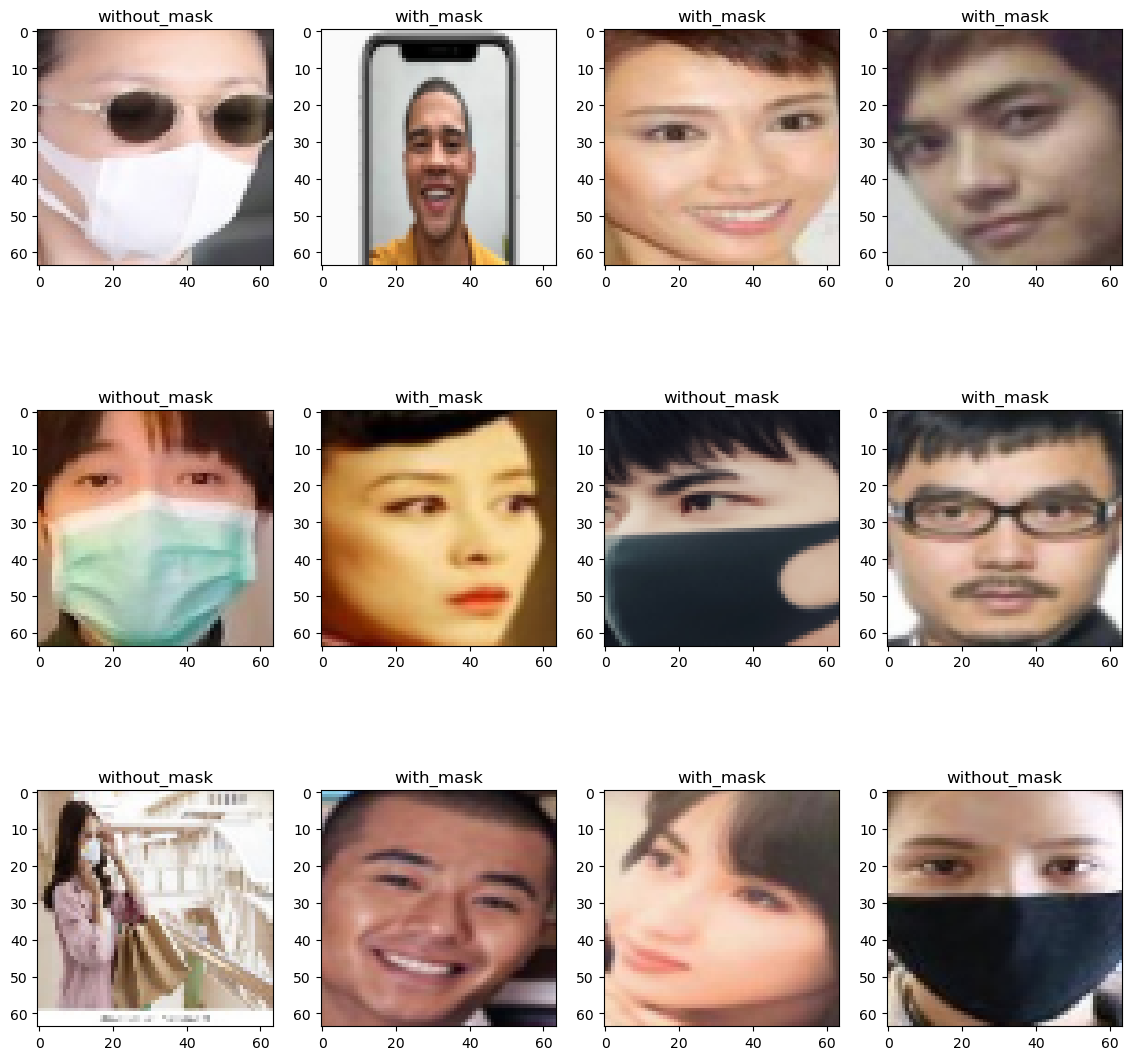

In [43]:
plt.figure(figsize=(14,14))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X_test[i])
    if pred[i] == 1:
        plt.title('with_mask')
    else:
        plt.title('without_mask')

### Plot confusion matrix on a heatmap

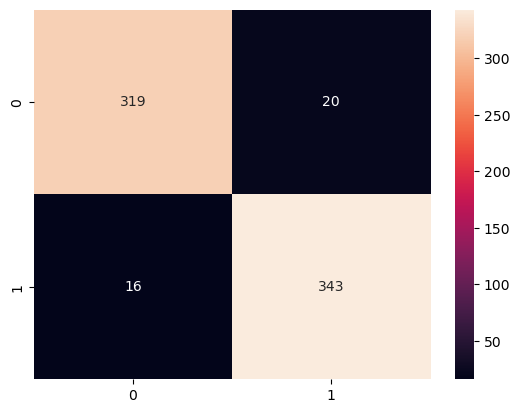

In [45]:
sns.heatmap(confusion_matrix(y_test,pred),annot=True,fmt='d')
plt.show()

### Classification report

In [47]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.95      0.94      0.95       339
           1       0.94      0.96      0.95       359

    accuracy                           0.95       698
   macro avg       0.95      0.95      0.95       698
weighted avg       0.95      0.95      0.95       698

